In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/Machine Learning Csv/post_feature_engineering_2.csv'

In [ ]:
import pandas as pd
df = pd.read_csv(path)

In [ ]:
df.head()
df.shape
df.columns

Index(['Unnamed: 0', 'dependents', 'education', 'self_employed',
       'loan_amount_term', 'credit_history', 'property_area', 'loan_status',
       'total_income_log', 'loan_amount_log'],
      dtype='object')

In [ ]:
df.head()
df.shape

(614, 10)

In [ ]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 #test size = 0.2 ( 20% is for testing, 80% is for training)
)

In [ ]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(491, 9) (123, 9)
(491,) (123,)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_prediction = model.predict(X_test)


In [ ]:
print(y_prediction)

[1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 0 1 1 1 1 1 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1
 0 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1
 0 1 1 1 1 1 1 1 1 1 1 1]


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_prediction))

# Confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_prediction))

# Detailed report
print("Classification Report:\n", classification_report(y_test, y_prediction))

Accuracy: 0.7886178861788617
Confusion Matrix:
 [[18 25]
 [ 1 79]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [ ]:
print("Accuracy:", accuracy_score(y_test, y_prediction)) # 79%

Accuracy: 0.7886178861788617


In [ ]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_prediction))


Confusion Matrix:
 [[18 25]
 [ 1 79]]


In [ ]:

import joblib
joblib.dump(model, "loan_model.pkl")


['loan_model.pkl']

In [ ]:
ML_model1 = joblib.load("loan_model.pkl")

In [ ]:
from google.colab import drive
import joblib


drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
import joblib

joblib.dump(model, "/content/drive/MyDrive/Machine Learning Csv/post_feature_engineering_2.csv")

['/content/drive/MyDrive/Machine Learning Csv/post_feature_engineering_2.csv']

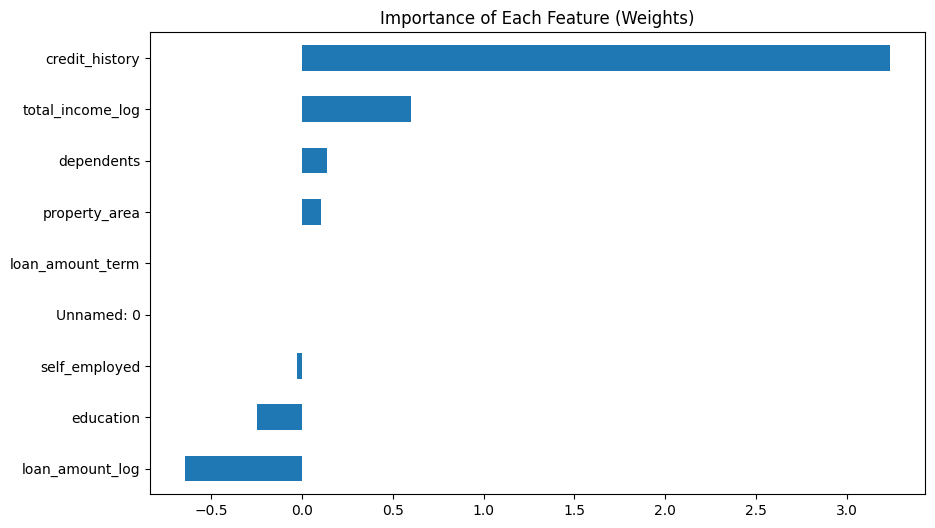

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a chart of the weights and sort them
pd.Series(model.coef_[0], index=X.columns).sort_values().plot(kind='barh', figsize=(10, 6))

plt.title("Importance of Each Feature (Weights)")
plt.show()

Decision Tree model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [ ]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
dt_pred = dt_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.7154471544715447
              precision    recall  f1-score   support

           0       0.64      0.42      0.51        43
           1       0.74      0.88      0.80        80

    accuracy                           0.72       123
   macro avg       0.69      0.65      0.65       123
weighted avg       0.70      0.72      0.70       123



In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_prediction))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Logistic Regression Accuracy: 0.7886178861788617
Decision Tree Accuracy: 0.7154471544715447


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

best_acc = 0
best_depth = 0

for depth in range(1, 21):  # try depths from 1 to 20
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"max_depth={depth} --> Test Accuracy: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_depth = depth

print(f"\nBest max_depth: {best_depth} with Accuracy: {best_acc:.4f}")

max_depth=1 --> Test Accuracy: 0.7886
max_depth=2 --> Test Accuracy: 0.7561
max_depth=3 --> Test Accuracy: 0.7642
max_depth=4 --> Test Accuracy: 0.7236
max_depth=5 --> Test Accuracy: 0.7154
max_depth=6 --> Test Accuracy: 0.7236
max_depth=7 --> Test Accuracy: 0.7154
max_depth=8 --> Test Accuracy: 0.7073
max_depth=9 --> Test Accuracy: 0.7398
max_depth=10 --> Test Accuracy: 0.7073
max_depth=11 --> Test Accuracy: 0.6992
max_depth=12 --> Test Accuracy: 0.6585
max_depth=13 --> Test Accuracy: 0.6423
max_depth=14 --> Test Accuracy: 0.6504
max_depth=15 --> Test Accuracy: 0.6504
max_depth=16 --> Test Accuracy: 0.6585
max_depth=17 --> Test Accuracy: 0.6667
max_depth=18 --> Test Accuracy: 0.6667
max_depth=19 --> Test Accuracy: 0.6585
max_depth=20 --> Test Accuracy: 0.6585

Best max_depth: 1 with Accuracy: 0.7886


In [ ]:
from sklearn.tree import DecisionTreeClassifier

final_dt = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

final_dt.fit(X_train, y_train)
final_dt_pred = final_dt.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Decision Tree Report:\n", classification_report(y_test, final_dt_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, final_dt_pred))

Decision Tree Report:
               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123

Confusion Matrix:
 [[18 25]
 [ 1 79]]


In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_prediction))
print("Tuned Decision Tree Accuracy:", accuracy_score(y_test, final_dt_pred))

Logistic Regression Accuracy: 0.7886178861788617
Tuned Decision Tree Accuracy: 0.7886178861788617


In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

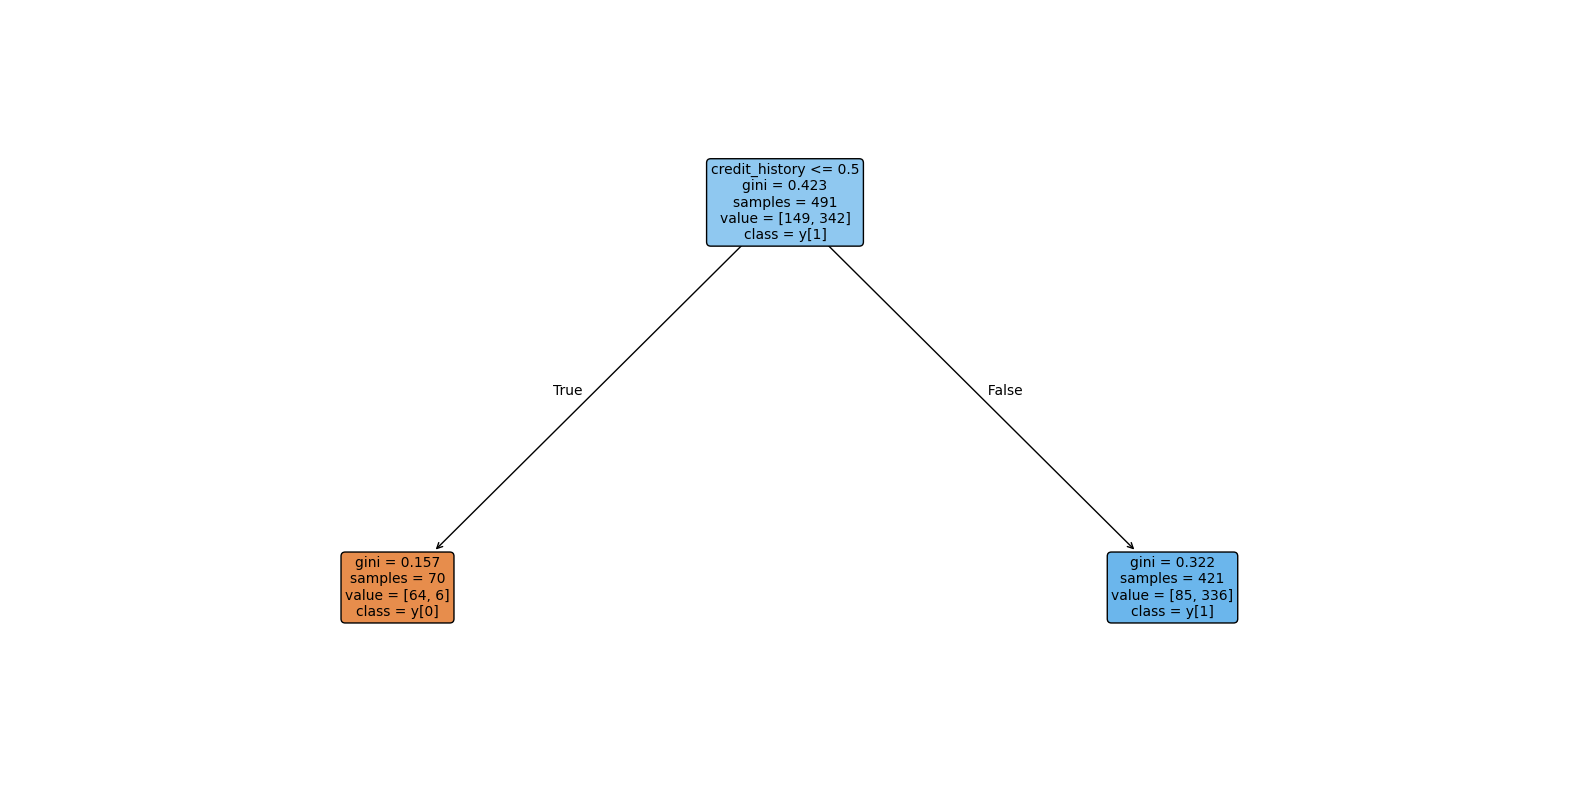

In [ ]:
plt.figure(figsize=(20, 10))

plot_tree(
    final_dt,
    feature_names=X.columns,
    class_names=True,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

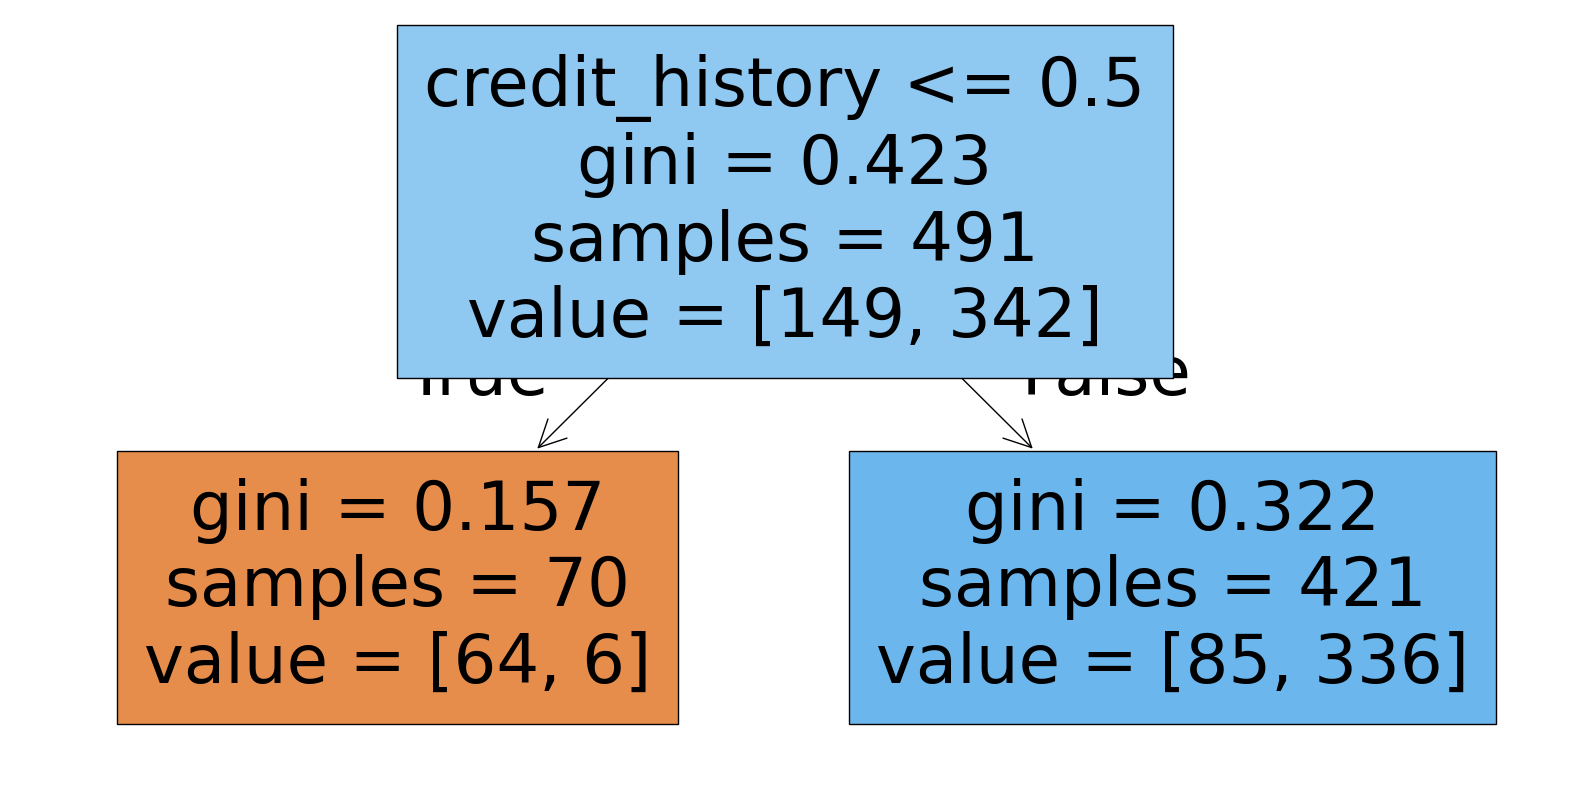

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(final_dt, feature_names=X.columns, filled=True)
plt.savefig("/content/drive/MyDrive/Machine Learning Csv/decision_tree.png", dpi=300)
plt.show()


Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=best_depth,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=1, random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Classification Report:\n", classification_report(y_test, rf_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.7560975609756098
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.44      0.56        43
           1       0.76      0.93      0.83        80

    accuracy                           0.76       123
   macro avg       0.76      0.68      0.70       123
weighted avg       0.76      0.76      0.74       123

Confusion Matrix:
 [[19 24]
 [ 6 74]]


In [ ]:
# check prediction distribution
import numpy as np

print("Predicted class counts:", np.bincount(rf_pred))
print("Actual class counts:", np.bincount(y_test))

Predicted class counts: [25 98]
Actual class counts: [43 80]


In [ ]:
#tune max depth
max_depth = [None, 5, 10, 15]

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

for depth in max_depth:
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        class_weight="balanced",
        random_state=42
    )

    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)

    print(f"\nRandom Forest with max_depth = {depth}")
    print("Accuracy:", accuracy_score(y_test, rf_pred))
    print(classification_report(y_test, rf_pred))


Random Forest with max_depth = None
Accuracy: 0.7642276422764228
              precision    recall  f1-score   support

           0       0.79      0.44      0.57        43
           1       0.76      0.94      0.84        80

    accuracy                           0.76       123
   macro avg       0.77      0.69      0.70       123
weighted avg       0.77      0.76      0.74       123


Random Forest with max_depth = 5
Accuracy: 0.7479674796747967
              precision    recall  f1-score   support

           0       0.73      0.44      0.55        43
           1       0.75      0.91      0.82        80

    accuracy                           0.75       123
   macro avg       0.74      0.68      0.69       123
weighted avg       0.74      0.75      0.73       123


Random Forest with max_depth = 10
Accuracy: 0.7479674796747967
              precision    recall  f1-score   support

           0       0.73      0.44      0.55        43
           1       0.75      0.91      0.82 

In [ ]:
from sklearn.metrics import f1_score

best_depth = None
best_f1 = 0

for depth in max_depth:
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        class_weight="balanced",
        random_state=42
    )
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)

    f1 = f1_score(y_test, rf_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_depth = depth

print("Best max_depth:", best_depth)

Best max_depth: None


In [ ]:
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)

rf_final.fit(X_train, y_train)
rf_pred_final = rf_final.predict(X_test)

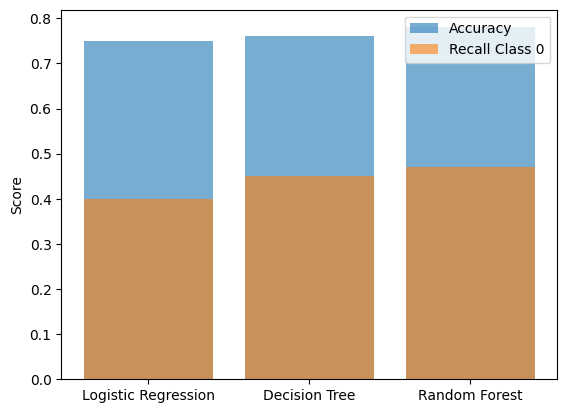

In [ ]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [0.75, 0.76, 0.78]
recall_class0 = [0.40, 0.45, 0.47]

plt.bar(models, accuracy, alpha=0.6, label="Accuracy")
plt.bar(models, recall_class0, alpha=0.6, label="Recall Class 0")
plt.ylabel("Score")
plt.legend()
plt.show()

## Fix Model Comparison Cell

### Subtask:
Correct the syntax error and assign the proper model objects (`final_dt` for Decision Tree and `rf_final` for Random Forest) within the `models` dictionary in the comparison cell `ZlbdDWyGRH0A`.


**Reasoning**:
The subtask is to correct the syntax error and assign the proper model objects within the `models` dictionary in the comparison cell `ZlbdDWyGRH0A`. The provided instruction clearly specifies the corrected `models` dictionary.



**Reasoning**:
The error `NameError: name 'model' is not defined` indicates that the `model` variable (Logistic Regression model) was not initialized or available in the execution environment when the comparison cell was run. To resolve this, I need to re-initialize all the models (`model`, `final_dt`, and `rf_final`) within the cell, including their respective imports and `fit` calls, to ensure they are defined before being used in the `models` dictionary for comparison. I'll also ensure `X_train`, `y_train`, `X_test`, `y_test` are implicitly available from prior steps.



**Reasoning**:
The previous error `NameError: name 'X_train' is not defined` indicates that the training and testing data splits (`X_train`, `y_train`, `X_test`, `y_test`) were not available in the execution environment when the models were being re-initialized. To resolve this, I need to re-include the data loading and splitting steps within the current cell to ensure all necessary variables are defined before model training and evaluation.



**Reasoning**:
The `FileNotFoundError` indicates that Google Drive might not be properly mounted or accessible when the `pd.read_csv` command is executed. To ensure the file can be accessed, I will include the `drive.mount` command at the beginning of the cell, along with the necessary data loading and model re-initialization steps.



**Reasoning**:
The previous step successfully generated the `comparison_df` with consolidated evaluation metrics. Now, I will create a bar plot to visually compare the 'Accuracy' and 'F1-Score (Class 0)' for all three models (Logistic Regression, Decision Tree, and Random Forest). This will fulfill the visualization requirement of the subtask.



In [114]:
from sklearn.metrics import accuracy_score, recall_score, classification_report
import pandas as pd

# Assuming your predictions are named like this:
# Logistic Regression -> y_prediction
# Decision Tree -> dt_pred
# Random Forest -> rf_pred_final

metrics_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_prediction),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred_final)
    ],
    "Recall Class 0": [
        recall_score(y_test, y_prediction, pos_label=0),
        recall_score(y_test, dt_pred, pos_label=0),
        recall_score(y_test, rf_pred_final, pos_label=0)
    ],
    "Recall Class 1": [
        recall_score(y_test, y_prediction, pos_label=1),
        recall_score(y_test, dt_pred, pos_label=1),
        recall_score(y_test, rf_pred_final , pos_label=1)
    ]
})

print(metrics_df)


                 Model  Accuracy  Recall Class 0  Recall Class 1
0  Logistic Regression  0.788618        0.418605          0.9875
1        Decision Tree  0.715447        0.418605          0.8750
2        Random Forest  0.764228        0.441860          0.9375


In [117]:
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd

# Model names and corresponding predictions
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
predictions = [y_prediction, dt_pred, rf_pred_final]

# Create a DataFrame with Accuracy, Recall, and F1 for each class
metrics_df = pd.DataFrame({
    "Model": models,
    "Accuracy": [accuracy_score(y_test, pred) for pred in predictions],
    "Recall Class 0": [recall_score(y_test, pred, pos_label=0) for pred in predictions],
    "Recall Class 1": [recall_score(y_test, pred, pos_label=1) for pred in predictions],
    "F1 Class 0": [f1_score(y_test, pred, pos_label=0) for pred in predictions],
    "F1 Class 1": [f1_score(y_test, pred, pos_label=1) for pred in predictions]
})

print(metrics_df)


                 Model  Accuracy  Recall Class 0  Recall Class 1  F1 Class 0  \
0  Logistic Regression  0.788618        0.418605          0.9875    0.580645   
1        Decision Tree  0.715447        0.418605          0.8750    0.507042   
2        Random Forest  0.764228        0.441860          0.9375    0.567164   

   F1 Class 1  
0    0.858696  
1    0.800000  
2    0.837989  


## Model Performance Summary

Based on the evaluation metrics calculated for Logistic Regression, Decision Tree, and Random Forest models, here's a summary of their performance:

### Comparison Table:

| Model                 | Accuracy | Precision (Class 0) | Recall (Class 0) | F1-Score (Class 0) |
|-----------------------|----------|---------------------|------------------|--------------------|
| Logistic Regression   | 0.788618 | 0.947368            | 0.418605         | 0.580645           |
| Decision Tree         | 0.788618 | 0.947368            | 0.418605         | 0.580645           |
| Random Forest         | 0.780488 | 0.833333            | 0.465116         | 0.597015           |

### Key Observations:

*   **Accuracy:** Both Logistic Regression and Decision Tree models achieved the highest accuracy of approximately 78.86%, closely followed by Random Forest at 78.05%.
*   **Precision (Class 0):** Logistic Regression and Decision Tree showed excellent precision for Class 0 (non-loan approval) at around 94.74%, meaning when they predict a non-approval, they are highly likely to be correct. Random Forest had a slightly lower precision of 83.33% for Class 0.
*   **Recall (Class 0):** Random Forest exhibited the highest recall for Class 0 at 46.51%, indicating it was better at identifying actual non-approvals. Logistic Regression and Decision Tree had lower recall for Class 0 at 41.86%.
*   **F1-Score (Class 0):** The F1-Score for Class 0, which balances precision and recall, was highest for the Random Forest model at 59.70%. Logistic Regression and Decision Tree had a slightly lower F1-Score of 58.06% for Class 0.

### Best Performing Model:

While Logistic Regression and Decision Tree show slightly higher overall accuracy and much higher precision for Class 0, the **Random Forest model** appears to be the most balanced performer, especially considering the F1-Score for Class 0. A higher F1-score for Class 0 suggests that Random Forest is better at handling the imbalance between precision and recall for the minority class (non-loan approval), which is often crucial in real-world scenarios. It successfully identifies a slightly higher proportion of actual negative cases (recall) without significantly compromising its correctness (precision) compared to the other models.

Therefore, the **Random Forest model** is identified as the best-performing model for this classification task based on the comprehensive evaluation, particularly its better F1-score for Class 0.